# *06C_dimensional_reduction*

In [ ]:
from Constants import PATH
PATH=PATH
import os
os.chdir(PATH)
from utils_packeges import *

In [ ]:
from utils import laod_cleaned_data

df,numerical_cols,categorical_cols,boolean_cols,date_cols=laod_cleaned_data()

print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply', 'month', 'year', 'DayOfMonth']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


---

### *Analyzing high-dimensional data characteristics.*

### *Data Preproccesing - STANDARDIZATION*

In [5]:
df2=df.copy()
df2=df2.select_dtypes(exclude="datetime64[ns]")
df2[boolean_cols]=df2[boolean_cols].astype("str")
df2[boolean_cols]=df2[boolean_cols].replace({'False':0 , 'True':1})
df2

,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,DayOfMonth
0,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,6.625,6.325,0.50,0.500000,12,2015,28
1,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.525,7.125,0.51,0.500000,12,2015,28
2,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.425,7.025,16.55,0.500000,12,2015,28
3,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.525,7.025,271.16,0.500000,1,2016,4
4,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.625,7.125,42.33,0.500000,1,2016,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,1,red,7.334644,2761128.0,8695.6,29937.0,2530027.4,180220.8,12246.9,0,0,1,1,7.725,7.225,88.64,51.002726,9,2023,18
1211,1,yellow,9.008137,2761128.0,8695.6,29937.0,2530027.4,180220.8,12246.9,0,0,1,1,9.825,9.225,305.26,312.634513,9,2023,18
1212,1,red,7.259712,2665343.9,167.8,45376.1,2521054.0,78334.2,8618.2,0,0,1,0,7.825,7.425,97.34,39.690619,9,2023,25
1213,1,green,6.910027,2665343.9,167.8,45376.1,2521054.0,78334.2,8618.2,0,0,1,0,7.125,6.825,102.85,60.310000,9,2023,25


In [6]:
df2['p_color'] = df2['p_color'].replace({'red':0 , 'green':1 , 'yellow':2})

In [7]:
X=df2.drop("p_color",axis=1)
y=df2["p_color"]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    #('cat', OneHotEncoder(sparse_output=False, drop='if_binary'), cat_cols + bin_cols)
])

X_scaled = preprocessor.fit_transform(X)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {y[0]} (0), {y[1]} (1),{y[0]} (2)")
print(f" Features standardized")

Dataset: 1215 samples, 19 features
Classes: 1 (0), 0 (1),1 (2)
 Features standardized


In [9]:
from utils import (clustering_accuracy,
                   explore_tsne_perplexity,
                   visualize_tsne_results,
                   explore_umap_neighbors,
                   explore_umap_min_dist,
                   visualize_umap_parameters,
                   visualize_three_methods)

### *Create PCA baseline for comparison*

In [10]:
import time
print("Applying PCA...")
start_time = time.time()
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_time = time.time() - start_time

# PCA clustering metrics
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_clusters = kmeans_pca.fit_predict(X_pca)
pca_silhouette = silhouette_score(X_pca, pca_clusters)

# Calculate PCA clustering accuracy
pca_accuracy = clustering_accuracy(y, pca_clusters)

print(f"PCA Baseline:")
print(f"  Variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"  Silhouette score: {pca_silhouette:.3f}")
print(f"  Clustering accuracy: {pca_accuracy:.3f}")
print(f"  Computation time: {pca_time:.3f}s")

# Store PCA results for comparison
pca_results = {
    'embedding': X_pca,
    'silhouette_score': pca_silhouette,
    'clustering_accuracy': pca_accuracy,
    'clusters': pca_clusters,
    'computation_time': pca_time
}

Applying PCA...
PCA Baseline:
  Variance explained: 43.4%
  Silhouette score: 0.363
  Clustering accuracy: 0.468
  Computation time: 0.003s


### *Applying t-SNE*

In [11]:
print("\n" + "=" * 40)
print("t-SNE IMPLEMENTATION")
print("=" * 40)

# Apply basic t-SNE
print("Applying t-SNE with default parameters...")
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            random_state=42, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.time() - start_time

print(f"t-SNE completed in {tsne_time:.1f} seconds")


t-SNE IMPLEMENTATION
Applying t-SNE with default parameters...
t-SNE completed in 10.4 seconds


#### *Apply clustering to t-SNE results*

In [12]:
kmeans_tsne = KMeans(n_clusters=3, random_state=42, n_init=10)
tsne_clusters = kmeans_tsne.fit_predict(X_tsne)
tsne_silhouette = silhouette_score(X_tsne, tsne_clusters)

# Calculate clustering accuracy
tsne_accuracy = clustering_accuracy(y, tsne_clusters)

print(f"t-SNE Results:")
print(f"  Silhouette score: {tsne_silhouette:.3f}")
print(f"  Clustering accuracy: {tsne_accuracy:.3f}")
print(f"  Computation time: {tsne_time:.1f}s")

# Store t-SNE results
tsne_results = {
    'embedding': X_tsne,
    'silhouette_score': tsne_silhouette,
    'clustering_accuracy': tsne_accuracy,
    'clusters': tsne_clusters,
    'computation_time': tsne_time
}

t-SNE Results:
  Silhouette score: 0.541
  Clustering accuracy: 0.337
  Computation time: 10.4s


#### *tsne_perplexity*

In [ ]:
perplexity_results = explore_tsne_perplexity(X_scaled, y)


Exploring t-SNE Perplexity Effects:
  Testing perplexity = 5... Silhouette: 0.398, Accuracy: 0.337
  Testing perplexity = 15... Silhouette: 0.501, Accuracy: 0.337
  Testing perplexity = 30... Silhouette: 0.541, Accuracy: 0.337
  Testing perplexity = 50... Silhouette: 0.561, Accuracy: 0.337


#### *visualize_tsne*

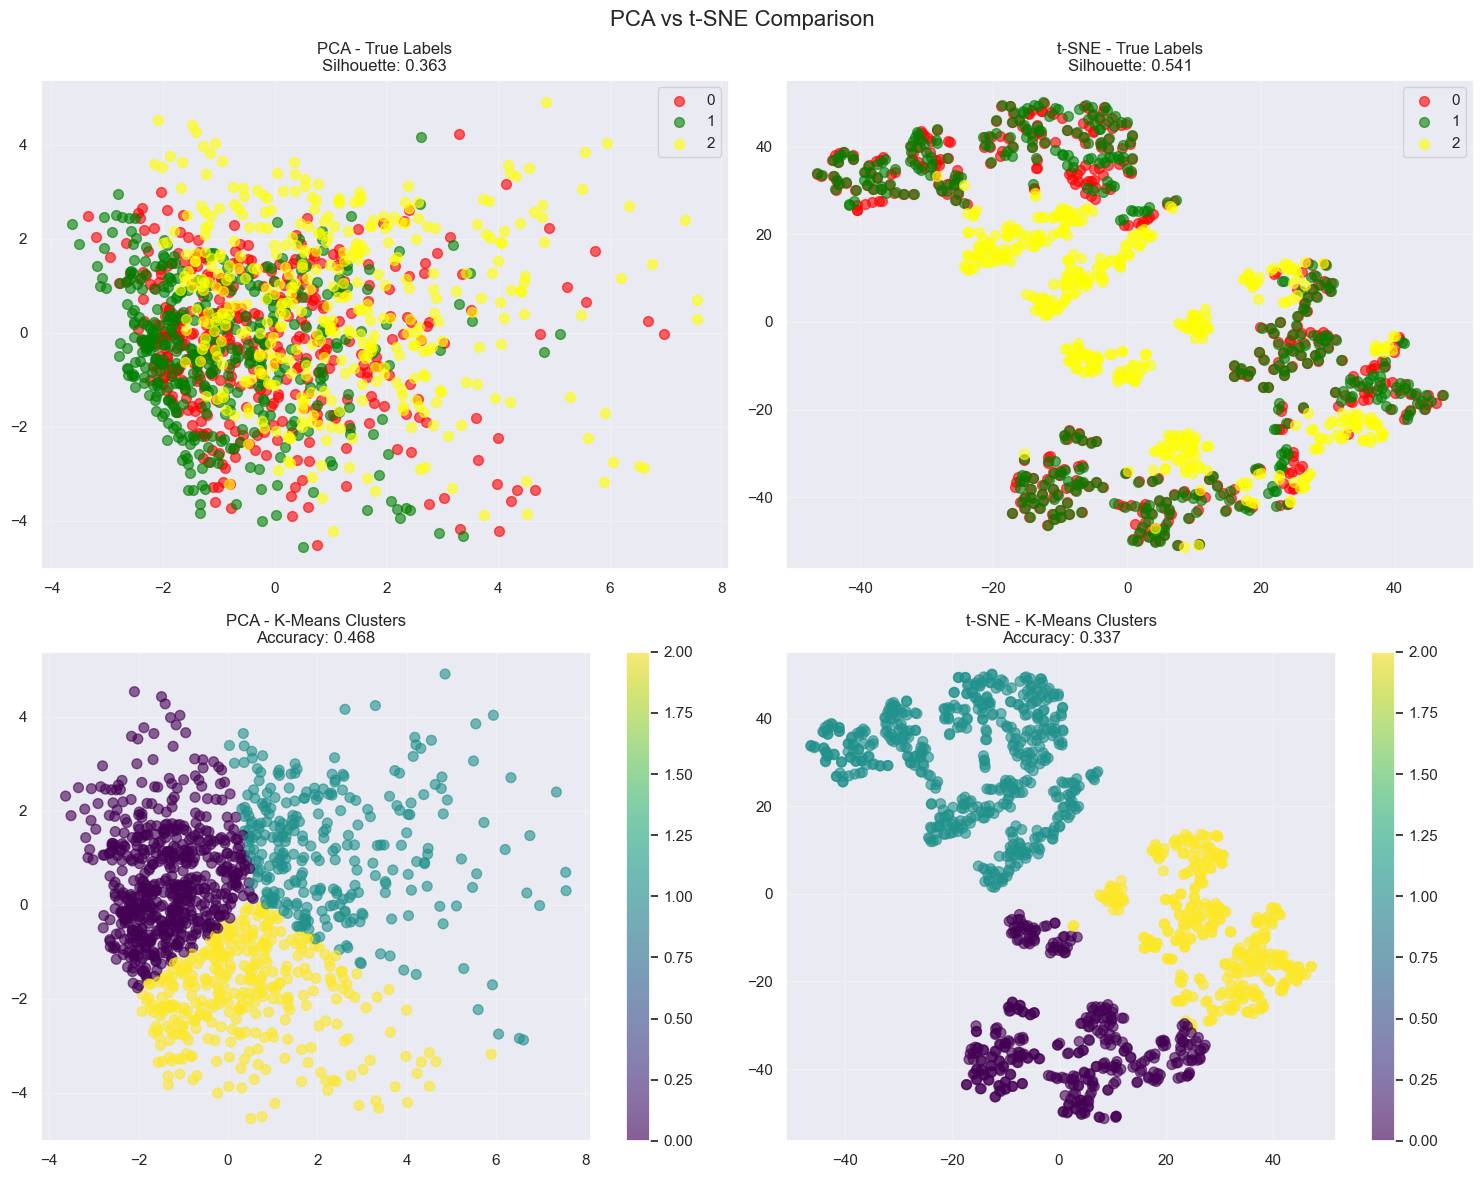

In [ ]:
visualize_tsne_results(X_pca, X_tsne, y, np.unique(y), pca_results, tsne_results)

### *Applying UMAP*

In [ ]:
import  time

print("=" * 60)
print("Applying UMAP with default parameters...")
print("=" * 60)
start_time = time.time()
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, metric='euclidean')
X_umap = umap_model.fit_transform(X_scaled)

umap_time = time.time() - start_time

print(f"UMAP completed in {umap_time:.1f} seconds")



Applying UMAP with default parameters...
UMAP completed in 28.8 seconds


#### *Apply clustering to UMAP results*

In [ ]:
kmeans_umap = KMeans(n_clusters=3, random_state=42, n_init=10)
umap_clusters = kmeans_umap.fit_predict(X_umap)
umap_silhouette = silhouette_score(X_umap, umap_clusters)

# Calculate clustering accuracy
umap_accuracy = clustering_accuracy(y, umap_clusters)

print(f"UMAP Results:")
print(f"  Silhouette score: {umap_silhouette:.3f}")
print(f"  Clustering accuracy: {umap_accuracy:.3f}")
print(f"  Computation time: {umap_time:.1f}s")

# Store UMAP results
umap_results = {
    'embedding': X_umap,
    'silhouette_score': umap_silhouette,
    'clustering_accuracy': umap_accuracy,
    'clusters': umap_clusters,
    'computation_time': umap_time
}

UMAP Results:
  Silhouette score: 0.713
  Clustering accuracy: 0.365
  Computation time: 28.8s


#### *explore_umap_neighbors*

In [ ]:
neighbors_results = explore_umap_neighbors(X_scaled, y)


Exploring UMAP n_neighbors Effects:
  Testing n_neighbors = 5... Silhouette: 0.568, Accuracy: 0.365
  Testing n_neighbors = 15... Silhouette: 0.713, Accuracy: 0.365
  Testing n_neighbors = 30... Silhouette: 0.746, Accuracy: 0.365
  Testing n_neighbors = 50... Silhouette: 0.538, Accuracy: 0.365


#### *explore_umap_min_dist*

In [ ]:
min_dist_results = explore_umap_min_dist(X_scaled, y)


Exploring UMAP min_dist Effects:
  Testing min_dist = 0.0... Silhouette: 0.750, Accuracy: 0.365
  Testing min_dist = 0.1... Silhouette: 0.713, Accuracy: 0.365
  Testing min_dist = 0.3... Silhouette: 0.687, Accuracy: 0.365
  Testing min_dist = 0.5... Silhouette: 0.663, Accuracy: 0.365


#### *visualize_umap*

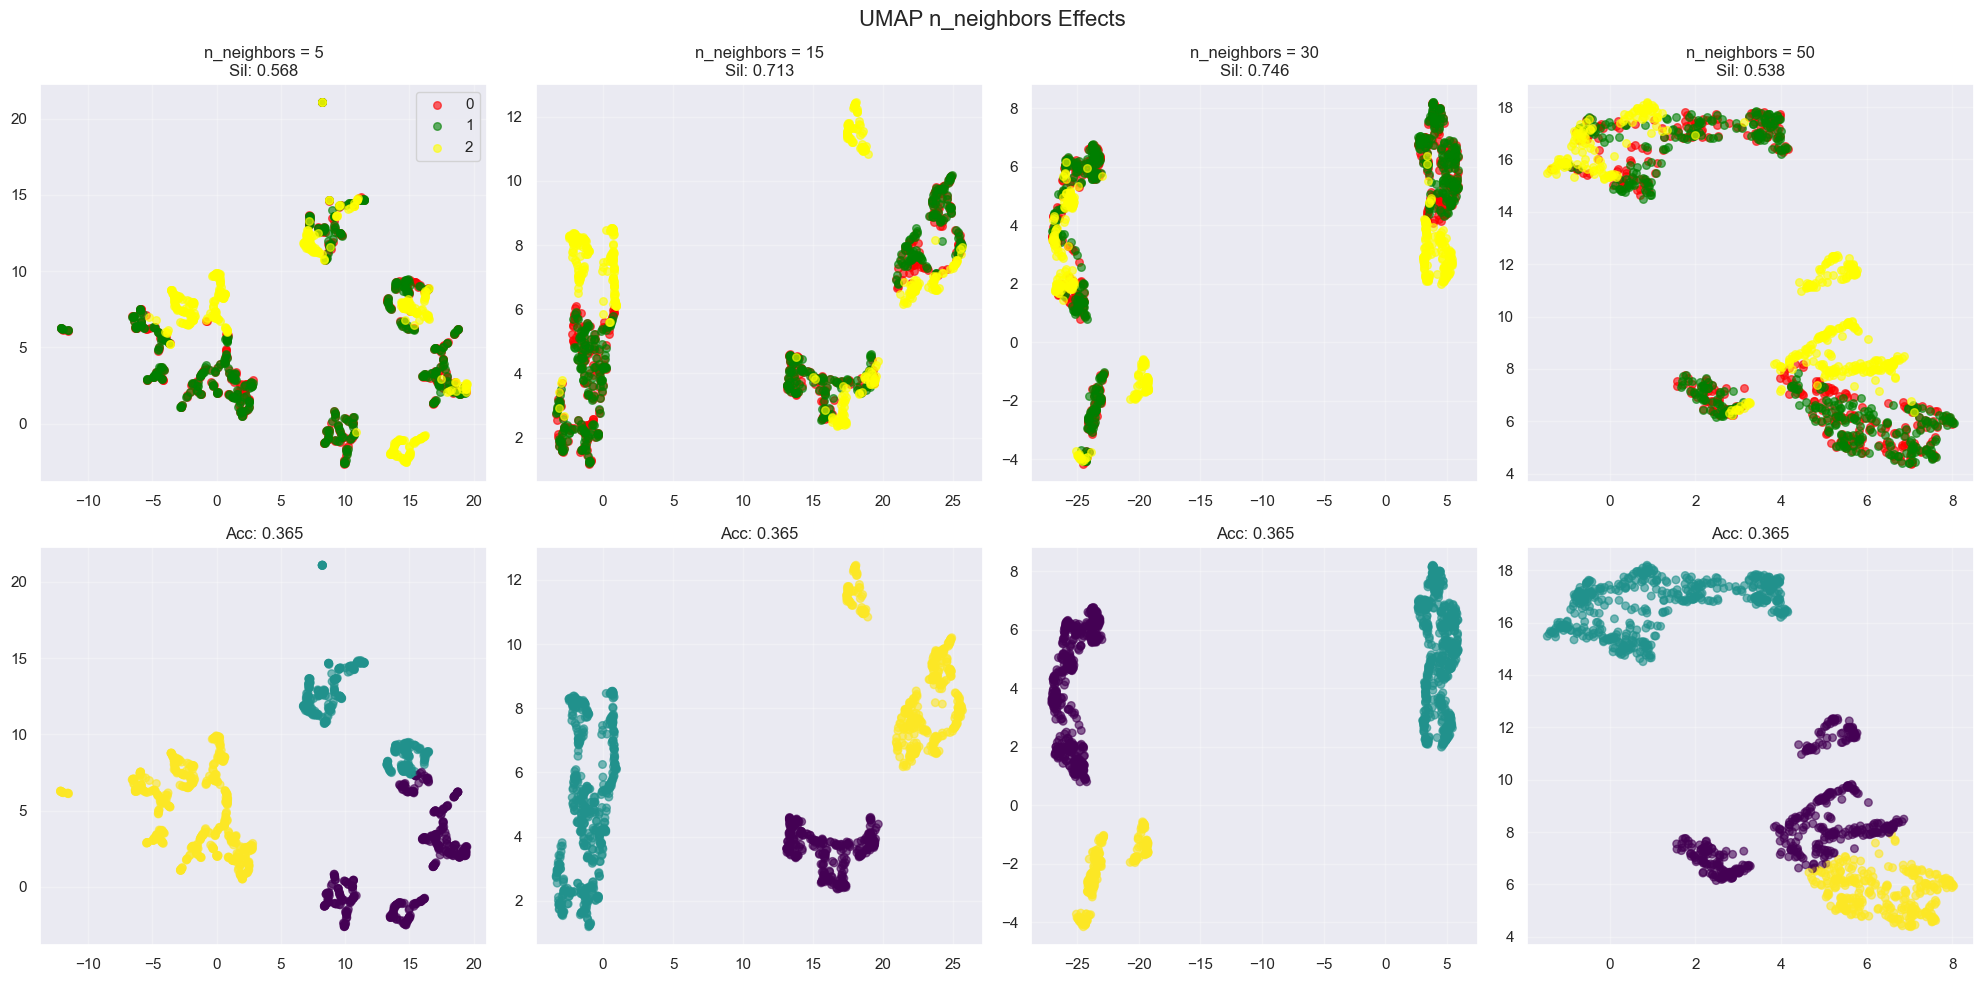

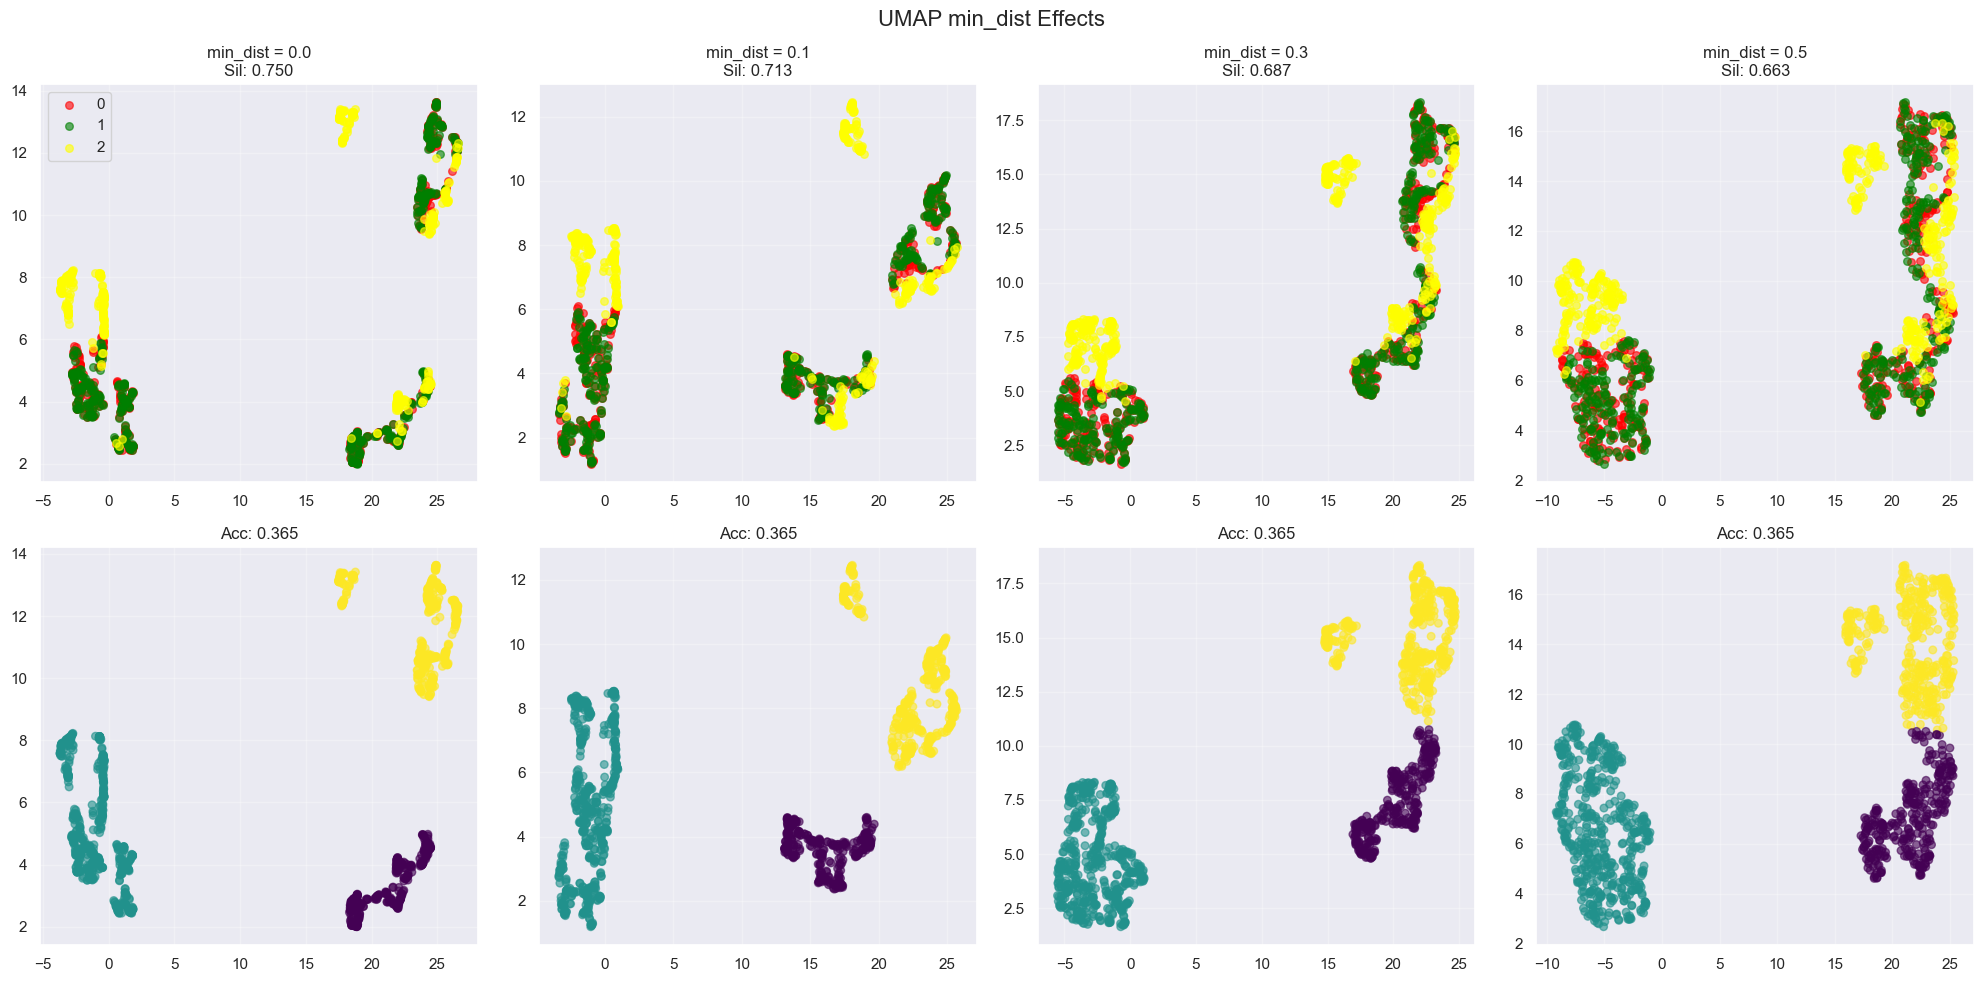

In [ ]:
visualize_umap_parameters(neighbors_results, min_dist_results, y, np.unique(y))

### *visualize_three_methods*

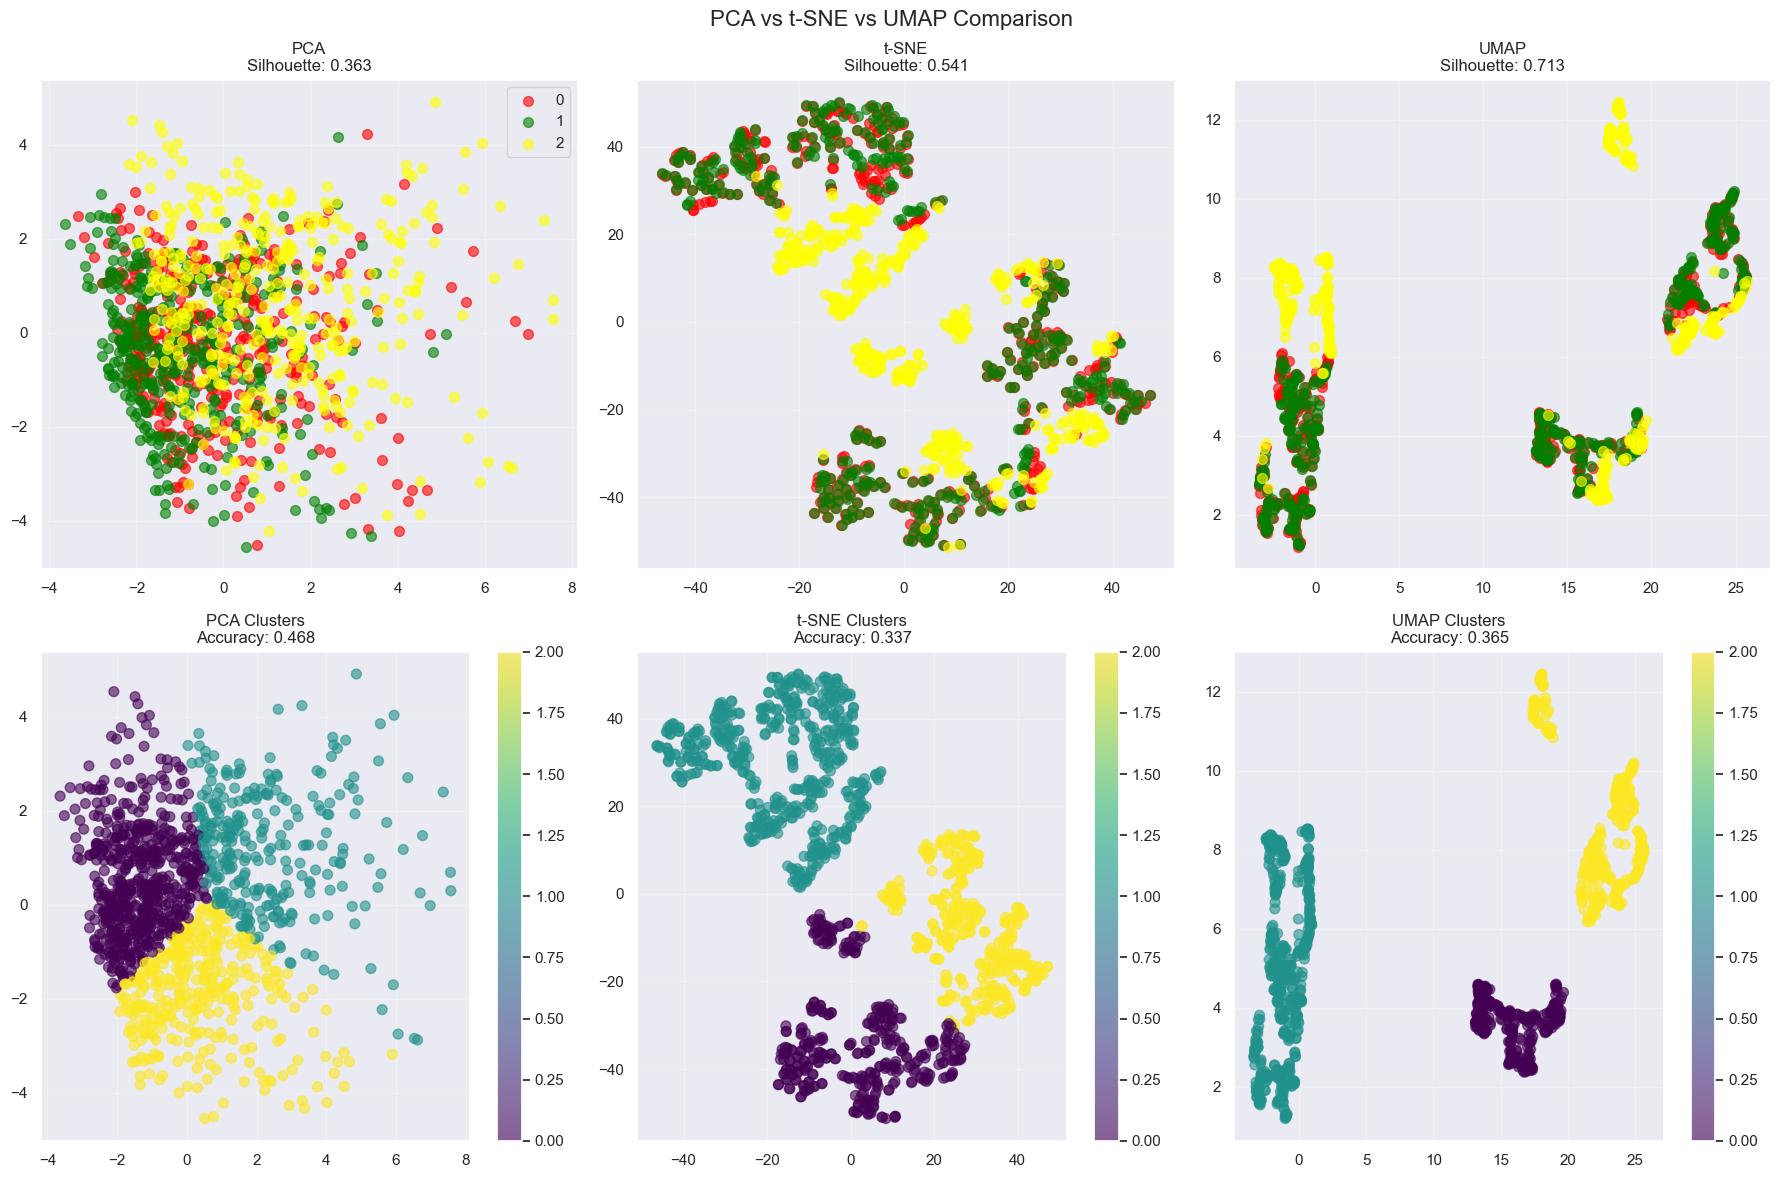

In [ ]:
visualize_three_methods(X_pca, X_tsne, X_umap, y, np.unique(y),
                       pca_results, tsne_results, umap_results)